### 1. Lecture Note

- 첫번째 시간 BigData Analytics 전반적인 내용, 앞으로 사용하게 될 데이터 종류, 용어에 익숙해지기
- 강의 중간 및 후반부에 다룰 핵심 내용 Trustworthy AI (신뢰 할수 있는 인공지능)
- "신뢰성"? 따질 수 있는 기준? 기본적으로 정확해야 함
- "HOW"? 모든 인종, 모든 기관, 모든 출처에 대해 정확해야 함
- 그래서 (이번주), 데이터 종류별  (다음주) 어떻게 예측 모델링을 진행하는지 다룬 다음 본격적으로 시작

### 2. Data Analytics 를 위한 주요 개념
1. Data Types
  - (1) Structured data: Tabular Data => 오늘 다룰 데이터
  - (2) Unstructured data: Image, Time-Series Data, Text Data ect.

2. ML models
 - classification: 범주 예측
 - regression: 수치 예측

3. Applications
  - (1) 제조, (2) 의료, (3) 금융, (4) 여러분 분야
  - 사이버캠퍼스 쪽지로 관심 데이터 및 분야 쪽지 (+간단한 자기소개) 보내주세요!

### 3. Data Analytics 를 위한 주요 프로그래밍
1. 데이터 로드 및 기초 분석
2. 데이터 전처리
3. 머신러닝 모델 적용 (예측 및 평가)






#### 1. 데이터 로드

- Titanic Data: 생존 여부(Survived)를 예측하는 이진 분류(Binary Classification) 문제


In [1]:
import pandas as pd
# 샘플 데이터 로드 (예: Kaggle 또는 Open Data)
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)

# 데이터 상위 5개 행 출력
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


**!!! NOTE !!!**
- 오늘 목표 1) 데이터 분석 시 필수적으로 수행해야하는 요소가 무엇인지? 살펴보는 시간
- 오늘 목표 2) 파이썬에서는 어떤 함수를 사용하는 지? 익숙해는 시간

**변수설명**
  - Survived : 생존 여부 (0 = 사망, 1 = 생존) → 타겟 변수
  - Pclass : 티켓 등급 (1 = 1등석, 2 = 2등석, 3 = 3등석)
  - Name : 승객 이름
  - Sex : 성별 (male, female)
  - Age : 나이 (숫자형)
  - SibSp : 함께 탑승한 형제자매 / 배우자 수
  - Parch : 함께 탑승한 부모 / 자녀 수
  - Ticket : 티켓 번호 (문자형)
  - Fare : 요금 (숫자형)
  - Cabin : 객실 번호 (결측치 多)
  - Embarked : 탑승 항구 (C = Cherbourg, Q = Queenstown, S = Southampton)
  - Survived가 예측 대상이며, Pclass, Sex, Age, Fare 등이 생존 여부와 관련이 높음!

In [2]:
# 데이터 기본 정보 확인
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB
None


- 위 정보를 보고 무슨 생각이 드세요?


**주요 분석 포인트: 생존 여부(Survived)와 관련된 인사이트를 찾기 위한 기초 분석**

- 성별(sex)과 생존율 분석
  - 여성 승객(female)의 생존율이 남성(male)보다 훨씬 높음
  - 이유: "여성과 아이들 먼저" 구조 원칙 때문

- 등급(Pclass)과 생존율 분석
  - 1등석 승객이 생존할 확률이 높음
  - 이유: 구조 과정에서 1등석 승객이 상대적으로 우선순위가 높았음

- 나이(Age)와 생존율 분석
  - 어린아이들이 생존할 확률이 높음

- 요금(Fare)과 생존율 분석
  - 높은 요금을 지불한 승객일수록 생존 가능성이 큼 (1등석 승객과 관련)

- 탑승 항구(Embarked)와 생존율 분석
  - Embarked = C (Cherbourg)에서 탑승한 승객이 생존율이 높음 (1등석 승객 비율이 높음)


sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


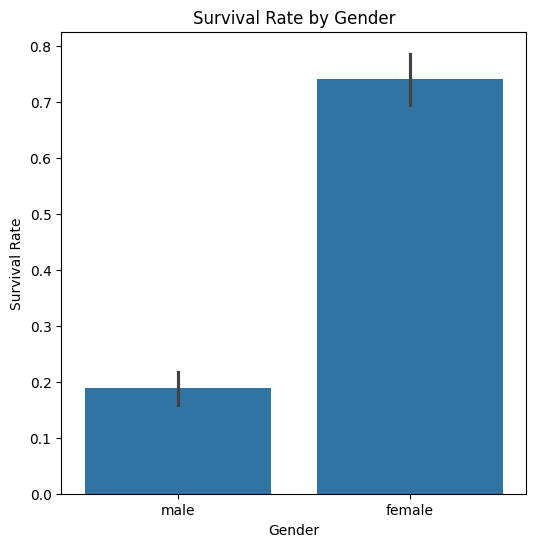

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 성별에 따른 생존율 계산
gender_survival = df.groupby("sex")["survived"].mean()
print(gender_survival)

# 성별 생존율 시각화
plt.figure(figsize=(6,6))
sns.barplot(x="sex", y="survived", data=df)
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.xlabel("Gender")
plt.show()

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


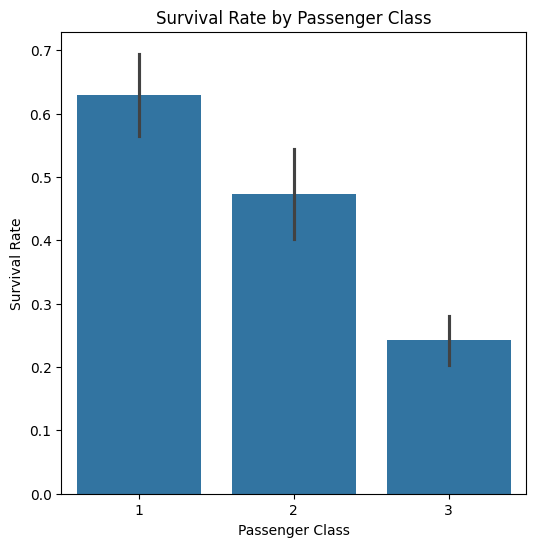

In [4]:
# 티켓 등급별 생존율 계산
pclass_survival = df.groupby("pclass")["survived"].mean()
print(pclass_survival)

# 티켓 등급별 생존율 시각화
plt.figure(figsize=(6,6))
sns.barplot(x="pclass", y="survived", data=df)
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.show()


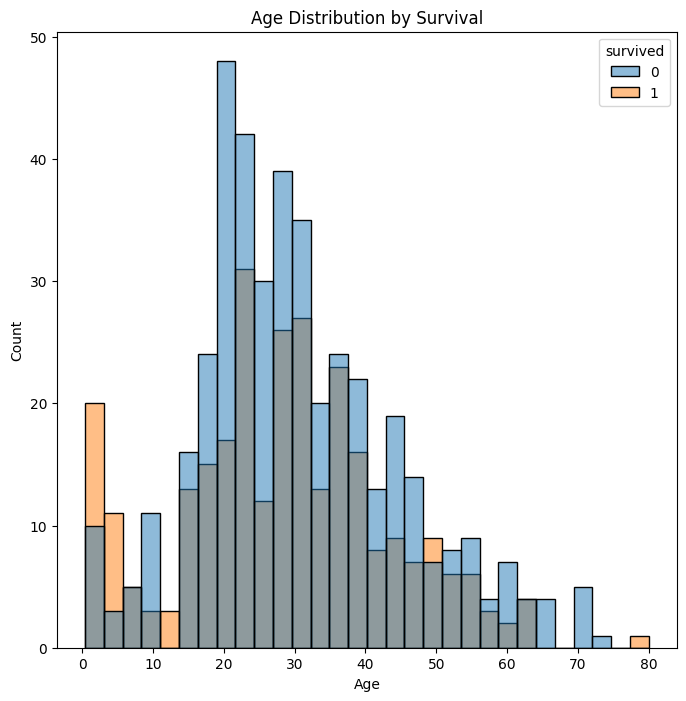

In [5]:
# 나이에 따른 생존율 시각화 (히스토그램)
plt.figure(figsize=(8,8))
sns.histplot(df, x="age", hue="survived", bins=30)
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

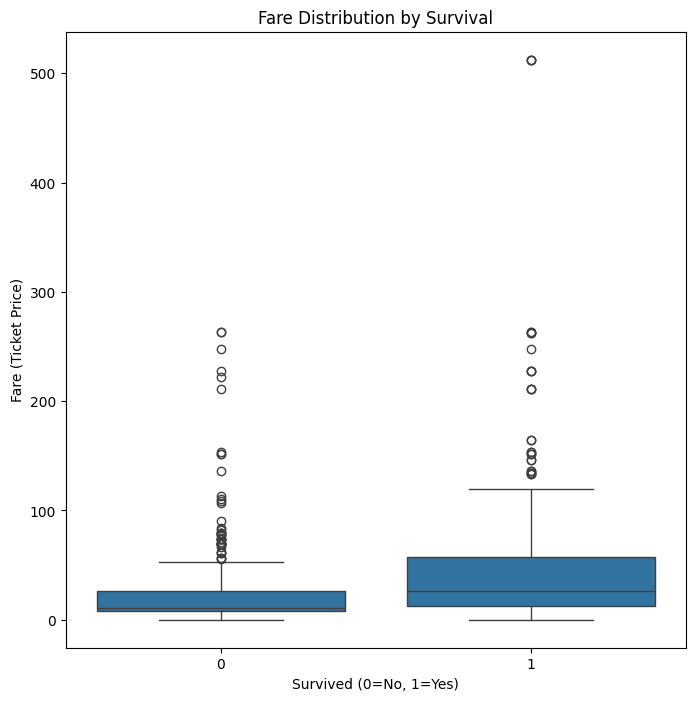

In [6]:
# 요금과 생존율 관계 시각화 (박스플롯)
plt.figure(figsize=(8,8))
sns.boxplot(x="survived", y="fare", data=df)
plt.title("Fare Distribution by Survival")
plt.ylabel("Fare (Ticket Price)")
plt.xlabel("Survived (0=No, 1=Yes)")
plt.show()

embarked
C    0.553571
Q    0.389610
S    0.336957
Name: survived, dtype: float64


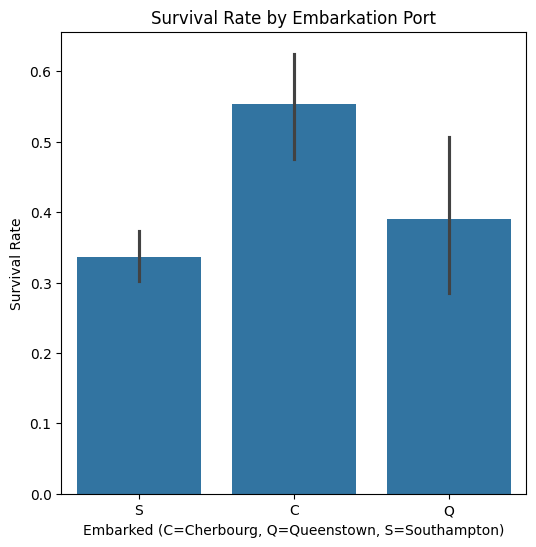

In [7]:
# 탑승 항구별 생존율 계산
embarked_survival = df.groupby("embarked")["survived"].mean()
print(embarked_survival)

# 탑승 항구별 생존율 시각화
plt.figure(figsize=(6,6))
sns.barplot(x="embarked", y="survived", data=df)
plt.title("Survival Rate by Embarkation Port")
plt.ylabel("Survival Rate")
plt.xlabel("Embarked (C=Cherbourg, Q=Queenstown, S=Southampton)")
plt.show()

pclass           1         2         3
embarked                              
C         0.505952  0.101190  0.392857
Q         0.025974  0.038961  0.935065
S         0.197205  0.254658  0.548137


<Figure size 500x500 with 0 Axes>

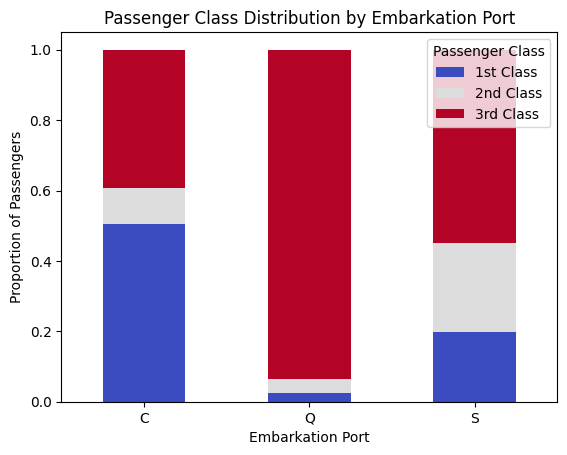

In [8]:
# 탑승 항구별 티켓 등급 비율 계산
embarked_pclass_counts = df.groupby("embarked")["pclass"].value_counts(normalize=True).unstack()
print(embarked_pclass_counts)

# 탑승 항구별 티켓 등급 시각화
plt.figure(figsize=(5,5))
embarked_pclass_counts.plot(kind="bar", stacked=True, colormap="coolwarm")
plt.title("Passenger Class Distribution by Embarkation Port")
plt.ylabel("Proportion of Passengers")
plt.xlabel("Embarkation Port")
plt.xticks(rotation=0)
plt.legend(title="Passenger Class", labels=["1st Class", "2nd Class", "3rd Class"])
plt.show()


pclass         1         2         3
sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447


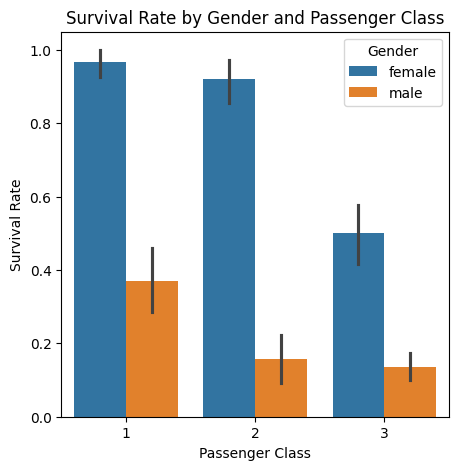

In [9]:
# 성별과 등급 조합별 생존율 계산
sex_pclass_survival = df.groupby(["sex", "pclass"])["survived"].mean().unstack()
print(sex_pclass_survival)

# 성별 + 등급 조합별 생존율 시각화
plt.figure(figsize=(5,5))
sns.barplot(x="pclass", y="survived", hue="sex", data=df)
plt.title("Survival Rate by Gender and Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.legend(title="Gender")
plt.show()


age_group
0-10     0.593750
10-20    0.382609
20-30    0.365217
30-40    0.445161
40-50    0.383721
50-60    0.404762
60-70    0.235294
70-80    0.200000
Name: survived, dtype: float64


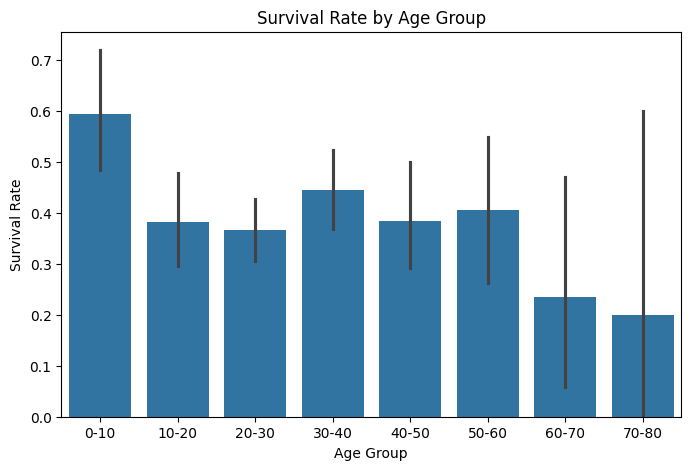

In [10]:
# 연령대 그룹 생성
df["age_group"] = pd.cut(df["age"], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80], labels=["0-10", "10-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80"])

# 연령대 그룹별 생존율 계산
age_group_survival = df.groupby("age_group", observed=False)["survived"].mean()
print(age_group_survival)
"""
observed=False → 모든 범주를 유지하면서 평균을 계산 (기본값, 기존 동작 유지)
observed=True → 데이터에 실제로 존재하는 범주만 유지 (불필요한 그룹을 제외하여 메모리 절약 가능)
"""
# 연령대 그룹별 생존율 시각화
plt.figure(figsize=(8,5))
sns.barplot(x="age_group", y="survived", data=df, order=["0-10", "10-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80"])
plt.title("Survival Rate by Age Group")
plt.ylabel("Survival Rate")
plt.xlabel("Age Group")
plt.show()

In [11]:
# 데이터 기본 정보 확인
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    object  
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    object  
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
 15  age_group    714 non-null    category
dtypes: bool(2), category(1), float64(2), int64(4), object(7)
memory usage: 93.6+ KB
None


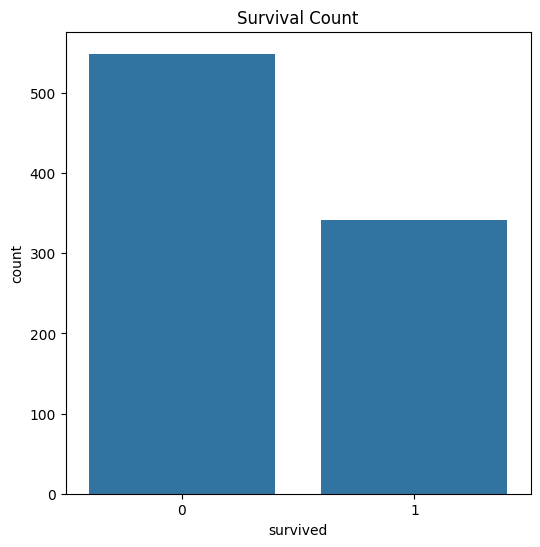

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 생존자 비율 시각화
plt.figure(figsize=(6,6))
sns.countplot(x="survived", data=df)
plt.title("Survival Count")
plt.show()

In [13]:
# 결측치 확인
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
age_group      177
dtype: int64


In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    object  
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    object  
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
 15  age_group    714 non-null    category
dtypes: bool(2), category(1), float64(2), int64(4), object(7)
memory usage: 93.6+ KB
None


#### 2. 데이터 전처리

In [15]:
import pandas as pd
# (1) pd.get_dummies
data = pd.get_dummies(df, drop_first=True)

# (2) 데이터 분할 (X 입력, Y 출력)
from sklearn.model_selection import train_test_split
X = data.drop('survived', axis=1)
y = data['survived']

# (3) 데이터 분할 (훈련 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:
numerical_cols = X_train.select_dtypes(include=['number']).columns
print(numerical_cols)

Index(['pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')


In [17]:
print(X_train.columns)

Index(['pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alone',
       'sex_male', 'embarked_Q', 'embarked_S', 'class_Second', 'class_Third',
       'who_man', 'who_woman', 'deck_B', 'deck_C', 'deck_D', 'deck_E',
       'deck_F', 'deck_G', 'embark_town_Queenstown', 'embark_town_Southampton',
       'alive_yes', 'age_group_10-20', 'age_group_20-30', 'age_group_30-40',
       'age_group_40-50', 'age_group_50-60', 'age_group_60-70',
       'age_group_70-80'],
      dtype='object')


In [18]:
# (3) imputation of training data and apply inputer to testing data
from sklearn.impute import SimpleImputer

print(numerical_cols)
imputer = SimpleImputer(strategy='mean')
X_train[numerical_cols] = imputer.fit_transform(X_train[numerical_cols]) # 학습데이터에서 평균을 찾은 다음 테스트에 적용
X_test[numerical_cols] = imputer.transform(X_test[numerical_cols]) # 테스트데이터는 "무조건" 학습 과정에서 참고가 되지 않아야 함

# (4) 정규화, 표준화: 머신러닝 모델링에서 전처리는 필수적: 변수별 숫자 단위를 맞추기 위함
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols]) # 학습데이터에서 평균을 찾은 다음 테스트에 적용
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols]) # 테스트데이터는 "무조건" 학습 과정에서 참고가 되지 않아야 함


Index(['pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 모델 학습 (랜덤 포레스트)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 예측 수행
y_pred = model.predict(X_test)

# 정확도 평가
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

# 상세 평가 보고서
print(classification_report(y_test, y_pred))

Accuracy: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        74

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



In [20]:
data.corr()

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_male,embarked_Q,...,embark_town_Queenstown,embark_town_Southampton,alive_yes,age_group_10-20,age_group_20-30,age_group_30-40,age_group_40-50,age_group_50-60,age_group_60-70,age_group_70-80
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,-0.557080,-0.203367,-0.543351,0.003650,...,0.003650,-0.155660,1.000000,-0.000973,-0.022586,0.057867,-0.000079,0.009569,-0.042599,-0.028398
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.094035,0.135207,0.131900,0.221009,...,0.221009,0.081720,-0.338481,0.102180,0.055285,-0.119900,-0.152566,-0.208905,-0.130057,-0.045728
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,0.280328,0.198270,0.093254,-0.022405,...,-0.022405,-0.032523,-0.077221,-0.373732,-0.203021,0.194160,0.399544,0.433886,0.367760,0.252232
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,-0.253586,-0.584471,-0.114631,-0.026354,...,-0.026354,0.070941,-0.035322,0.023855,-0.107723,-0.061964,-0.044756,-0.043083,-0.043852,-0.035649
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,-0.349943,-0.583398,-0.245489,-0.081228,...,-0.081228,0.063036,0.081629,0.004640,-0.104314,0.006810,0.019734,-0.019898,-0.004960,-0.035583
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,-0.182024,-0.271832,-0.182333,-0.117216,...,-0.117216,-0.166603,0.257307,-0.020732,-0.046291,0.095097,0.058960,0.056295,0.038490,-0.009480
adult_male,-0.557080,0.094035,0.280328,-0.253586,-0.349943,-0.182024,1.000000,0.404744,0.908578,-0.076789,...,-0.076789,0.112035,-0.557080,-0.050005,0.054405,0.039827,0.024608,0.029077,0.062940,0.060993
alone,-0.203367,0.135207,0.198270,-0.584471,-0.583398,-0.271832,0.404744,1.000000,0.303646,0.086464,...,0.086464,0.024929,-0.203367,-0.029482,0.096334,-0.008576,-0.045293,-0.003389,0.046175,0.060993
sex_male,-0.543351,0.131900,0.093254,-0.114631,-0.245489,-0.182333,0.908578,0.303646,1.000000,-0.074115,...,-0.074115,0.125722,-0.543351,-0.038347,0.000295,-0.002330,-0.005509,0.008883,0.051365,0.055417
embarked_Q,0.003650,0.221009,-0.022405,-0.026354,-0.081228,-0.117216,-0.076789,0.086464,-0.074115,1.000000,...,1.000000,-0.496624,0.003650,-0.046919,-0.126659,-0.067385,-0.073475,-0.049561,-0.013697,0.030366


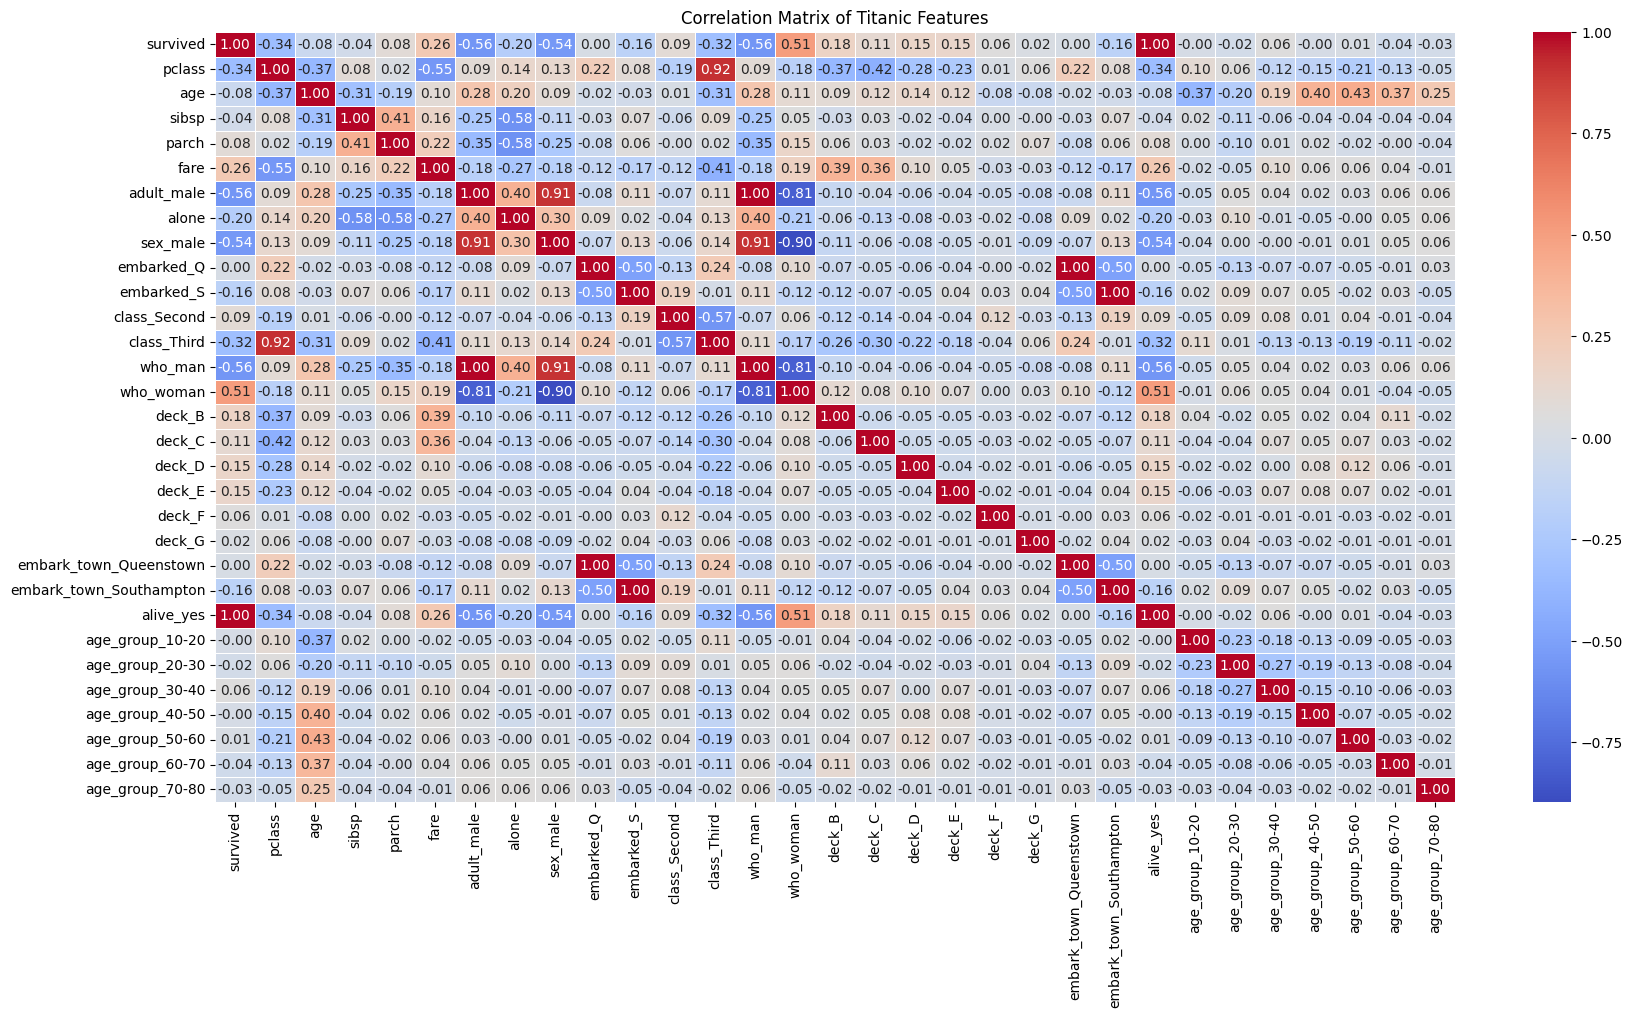

In [21]:
plt.figure(figsize=(20,10))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Titanic Features")
plt.show()

### Summary
- 주요 특성(Feature): 성별(Sex), 티켓 등급(Pclass), 나이(Age), 요금(Fare) 등이 생존 여부와 높은 상관관계가 있음
- 머신러닝 모델 적용 가능: 신경망, 랜덤 포레스트, 로지스틱 회귀, SVM, XGBoost 등 다양한 알고리즘 활용 가능
- 실제 적용 가능성: 같은 분석 방법을 제조 (정상/불량), 금융(고객 이탈 여부), 의료(사망 여부) 등 다양한 분야에 응용 가능

### Note !!!
- 실험할 때 (프로젝트, 과제, 발표, 논문, 등등 데이터 분석, 예측모델링, 인공지능 분야 내) 필수 사항
  - 최소 "여러개" 모델 "여러번" 실험을 진행해서 평균적인 성능을 나타내야 함
- 이때 여러번 기준이 되는 게 바로 Random Seed
  - 여러분이 직접, 데이터 분할 기준, 반복실험을 진행해 보세요!
- 다음시간에는 인공신경망 기반 예측모델링을 중점적으로 오프라인 강의 진행
  - epoch, model selection 중심으로

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
# 반복실험
n_replications = 10
for random_seed in range(n_replications):
  """
  직접 코드 작성
  """
  print(random_seed)

0
1
2
3
4
5
6
7
8
9
